<a href="https://colab.research.google.com/github/vvamsi91/HGR_Project/blob/main/HGR_tran.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# New section

In [16]:
import os
import argparse
from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
import torch
import torch.nn as nn
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

In [17]:
import kagglehub
gti_upm_leapgestrecog_path = kagglehub.dataset_download('gti-upm/leapgestrecog')

print('Data source import complete.')

Data source import complete.


In [7]:
import os
import numpy as np
import pandas as pd

# Define the input directory
input_dir = '/kaggle/input'

# Explore the directory structure
file_list = []
for root, _, files in os.walk(input_dir):
    for file in files:
        file_path = os.path.join(root, file)
        file_list.append(file_path)

print("Images are downloaded.")

Images are downloaded.


In [19]:
class HandGestureDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.samples = []
        self.transform = transform
        for subject in os.listdir(root_dir):
            subject_path = os.path.join(root_dir, subject)
            if not os.path.isdir(subject_path):
                continue
            for gesture in os.listdir(subject_path):
                gesture_path = os.path.join(subject_path, gesture)
                if not os.path.isdir(gesture_path):
                    continue
                for img_name in os.listdir(gesture_path):
                    if img_name.endswith('.png'):
                        img_path = os.path.join(gesture_path, img_name)
                        self.samples.append((img_path, gesture))
        self.gesture_to_idx = {g: i for i, g in enumerate(sorted(set(x[1] for x in self.samples)))}
        self.idx_to_gesture = {i: g for g, i in self.gesture_to_idx.items()}
        self.samples = [(img, self.gesture_to_idx[label]) for img, label in self.samples]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

In [9]:

    def __len__(self):
        return len(self.samples)

In [10]:
   def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

In [11]:
def plot_metrics(train_losses, train_accuracies, val_losses, val_accuracies):
    epochs = range(1, len(train_losses) + 1)
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label='Train Loss')
    plt.plot(epochs, val_losses, label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Loss over Epochs')
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracies, label='Train Acc')
    plt.plot(epochs, val_accuracies, label='Val Acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Accuracy over Epochs')
    plt.tight_layout()
    plt.show()


In [12]:
def evaluate(model, dataloader, device):
    model.eval()
    correct = 0
    total = 0
    running_loss = 0.0
    criterion = nn.CrossEntropyLoss()
    all_labels = []
    all_preds = []
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())
    avg_loss = running_loss / total
    accuracy = correct / total
    return avg_loss, accuracy, np.array(all_labels), np.array(all_preds)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ViT_B_16_Weights.IMAGENET1K_V1`. You can also use `weights=ViT_B_16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth
100%|██████████| 330M/330M [00:02<00:00, 171MB/s]
Epoch 1/10 - Training: 100%|██████████| 438/438 [07:39<00:00,  1.05s/it]


Epoch 1: Train Loss=0.0814, Train Acc=0.9769, Val Loss=0.0037, Val Acc=0.9990


Epoch 2/10 - Training: 100%|██████████| 438/438 [07:44<00:00,  1.06s/it]


Epoch 2: Train Loss=0.0277, Train Acc=0.9914, Val Loss=0.0006, Val Acc=1.0000


Epoch 3/10 - Training: 100%|██████████| 438/438 [07:44<00:00,  1.06s/it]


...

Epoch 8: Train Loss=0.0001, Train Acc=1.0000, Val Loss=0.0003, Val Acc=1.0000


Epoch 9/10 - Training: 100%|██████████| 438/438 [07:44<00:00,  1.06s/it]


Epoch 9: Train Loss=0.0001, Train Acc=1.0000, Val Loss=0.0002, Val Acc=1.0000


Epoch 10/10 - Training: 100%|██████████| 438/438 [07:44<00:00,  1.06s/it]


Epoch 10: Train Loss=0.0001, Train Acc=1.0000, Val Loss=0.0002, Val Acc=1.0000
Training complete. Model saved as hand_gesture_vit.pth


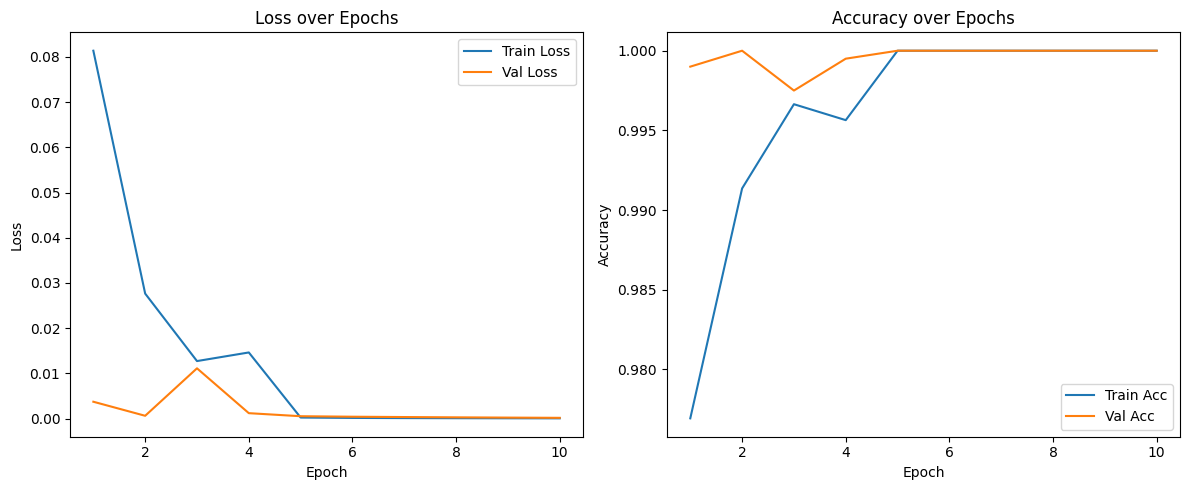

Test Loss: 0.0009, Test Accuracy: 0.9998


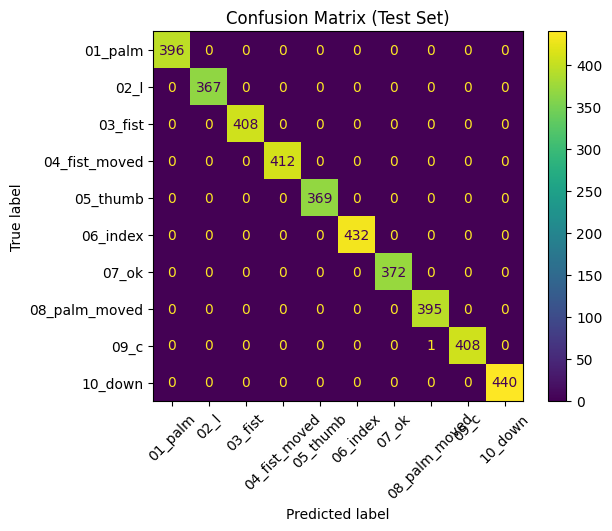

In [20]:
def main():
    # Define parameters directly instead of using argparse
    data_dir = "/kaggle/input/leapgestrecog/leapGestRecog/"
    epochs = 10
    batch_size = 32
    lr = 1e-4
    num_workers = 2
    test_split = 0.2
    val_split = 0.1

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    dataset = HandGestureDataset(data_dir, transform=transform)
    num_classes = len(dataset.gesture_to_idx)
    n_total = len(dataset)
    n_test = int(n_total * test_split)
    n_val = int(n_total * val_split)
    n_train = n_total - n_test - n_val
    train_set, val_set, test_set = random_split(dataset, [n_train, n_val, n_test], generator=torch.Generator().manual_seed(42))
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=num_workers)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = models.vit_b_16(pretrained=True)
    model.heads.head = nn.Linear(model.heads.head.in_features, num_classes)
    model = model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    train_losses, train_accuracies = [], []
    val_losses, val_accuracies = [], []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        for images, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs} - Training'):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        epoch_loss = running_loss / total
        epoch_acc = correct / total
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_acc)

        val_loss, val_acc, _, _ = evaluate(model, val_loader, device)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)
        print(f'Epoch {epoch+1}: Train Loss={epoch_loss:.4f}, Train Acc={epoch_acc:.4f}, Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}')

    torch.save(model.state_dict(), 'hand_gesture_vit.pth')
    print('Training complete. Model saved as hand_gesture_vit.pth')

    plot_metrics(train_losses, train_accuracies, val_losses, val_accuracies)

    # Test and confusion matrix
    test_loss, test_acc, test_labels, test_preds = evaluate(model, test_loader, device)
    print(f'Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}')
    cm = confusion_matrix(test_labels, test_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[dataset.idx_to_gesture[i] for i in range(num_classes)])
    disp.plot(xticks_rotation=45)
    plt.title('Confusion Matrix (Test Set)')
    plt.show()

if __name__ == '__main__':
    main()

Number of samples: 20000
Number of classes: 10


Epoch 1/10 - Training: 100%|██████████| 188/188 [06:40<00:00,  2.13s/it]


Epoch 1: Train Loss=0.0697, Train Acc=0.9834, Val Loss=0.4803, Val Acc=0.8440


Epoch 2/10 - Training: 100%|██████████| 188/188 [06:40<00:00,  2.13s/it]


Epoch 2: Train Loss=0.0334, Train Acc=0.9902, Val Loss=0.0163, Val Acc=0.9965


...

Epoch 8: Train Loss=0.0001, Train Acc=1.0000, Val Loss=0.0002, Val Acc=1.0000


Epoch 9/10 - Training: 100%|██████████| 188/188 [06:40<00:00,  2.13s/it]


Epoch 9: Train Loss=0.0001, Train Acc=1.0000, Val Loss=0.0002, Val Acc=1.0000


Epoch 10/10 - Training: 100%|██████████| 188/188 [06:40<00:00,  2.13s/it]


Epoch 10: Train Loss=0.0001, Train Acc=1.0000, Val Loss=0.0002, Val Acc=1.0000
Training complete. Model saved as hand_gesture_vit.pth


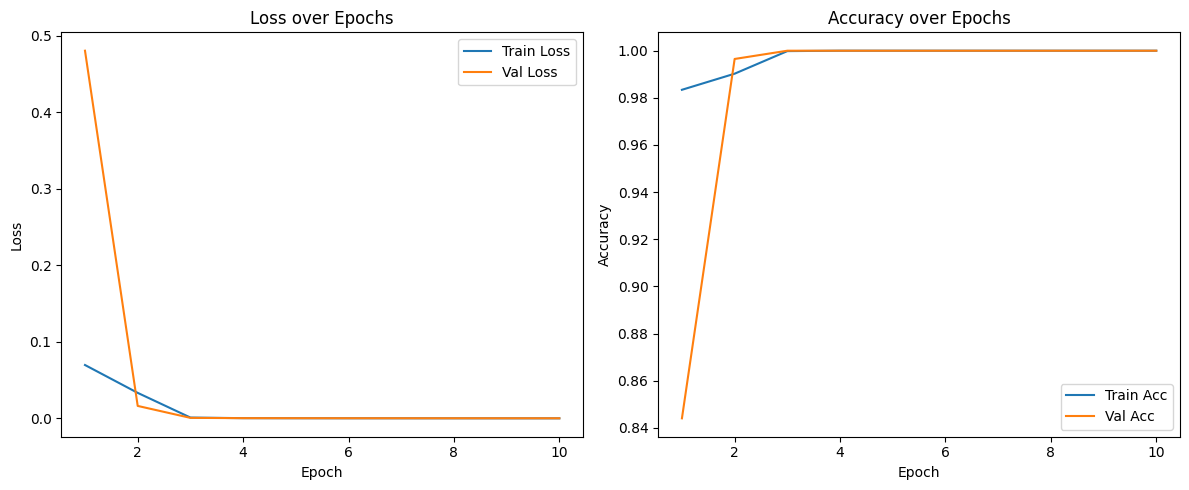

Test Loss: 0.0001, Test Accuracy: 1.0000


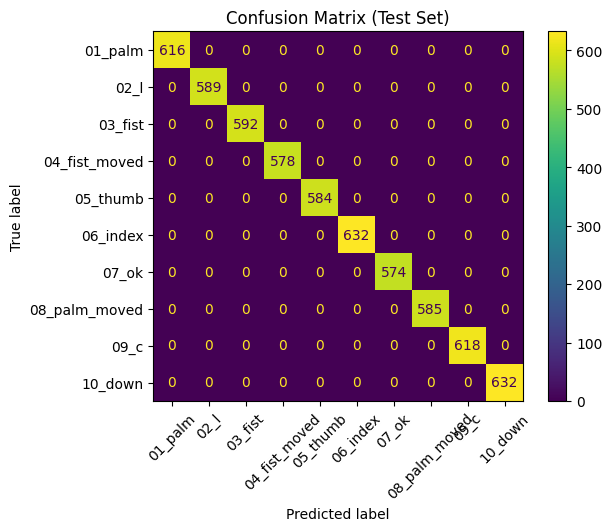

In [24]:
def main():
    # Define parameters directly instead of using argparse
    data_dir = "/kaggle/input/leapgestrecog/leapGestRecog/"
    epochs = 10
    batch_size = 64
    lr = 1e-4
    num_workers = 2
    test_split = 0.3
    val_split = 0.1

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    dataset = HandGestureDataset(data_dir, transform=transform)
    num_classes = len(dataset.gesture_to_idx)
    n_total = len(dataset)
    print(f"Number of samples: {n_total}")
    print(f"Number of classes: {num_classes}")
    n_test = int(n_total * test_split)
    n_val = int(n_total * val_split)
    n_train = n_total - n_test - n_val
    train_set, val_set, test_set = random_split(dataset, [n_train, n_val, n_test], generator=torch.Generator().manual_seed(42))
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=num_workers)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = models.vit_b_16(pretrained=True)
    model.heads.head = nn.Linear(model.heads.head.in_features, num_classes)
    model = model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    train_losses, train_accuracies = [], []
    val_losses, val_accuracies = [], []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        for images, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs} - Training'):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        epoch_loss = running_loss / total
        epoch_acc = correct / total
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_acc)

        val_loss, val_acc, _, _ = evaluate(model, val_loader, device)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)
        print(f'Epoch {epoch+1}: Train Loss={epoch_loss:.4f}, Train Acc={epoch_acc:.4f}, Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}')

    torch.save(model.state_dict(), 'hand_gesture_vit.pth')
    print('Training complete. Model saved as hand_gesture_vit.pth')

    plot_metrics(train_losses, train_accuracies, val_losses, val_accuracies)

    # Test and confusion matrix
    test_loss, test_acc, test_labels, test_preds = evaluate(model, test_loader, device)
    print(f'Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}')
    cm = confusion_matrix(test_labels, test_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[dataset.idx_to_gesture[i] for i in range(num_classes)])
    disp.plot(xticks_rotation=45)
    plt.title('Confusion Matrix (Test Set)')
    plt.show()

if __name__ == '__main__':
    main()

Number of samples: 20000
Number of classes: 10


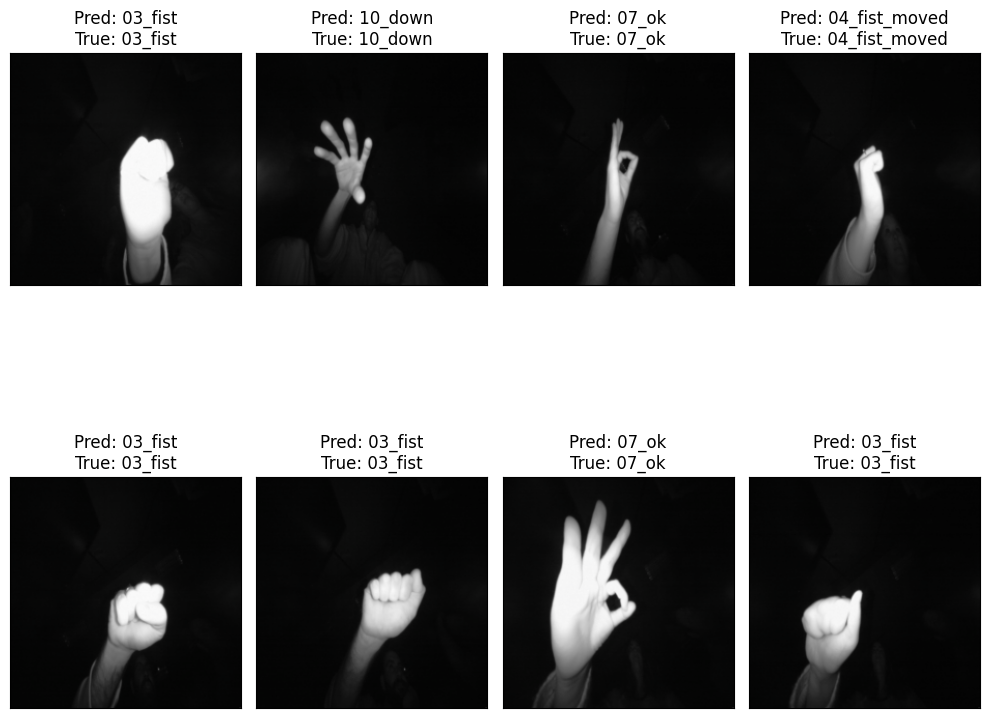

In [30]:
# Load the saved model
data_dir = "/kaggle/input/leapgestrecog/leapGestRecog/"
epochs = 10
batch_size = 64
lr = 1e-4
num_workers = 2
test_split = 0.3
val_split = 0.1

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

dataset = HandGestureDataset(data_dir, transform=transform)
num_classes = len(dataset.gesture_to_idx)
n_total = len(dataset)
print(f"Number of samples: {n_total}")
print(f"Number of classes: {num_classes}")
n_test = int(n_total * test_split)
n_val = int(n_total * val_split)
n_train = n_total - n_test - n_val
train_set, val_set, test_set = random_split(dataset, [n_train, n_val, n_test], generator=torch.Generator().manual_seed(42))
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=num_workers)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=num_workers)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = models.vit_b_16(pretrained=True)
num_classes = 10 #len(dataset.gesture_to_idx) # Use the num_classes from the previous run
model.heads.head = nn.Linear(model.heads.head.in_features, num_classes)
model.load_state_dict(torch.load('hand_gesture_vit.pth'))
model.to("cuda")
model.eval() # Set the model to evaluation mode

# Get a few images from the test set for inference
dataiter = iter(test_loader)
images, labels = next(dataiter)

# Perform inference
images, labels = images.to(device), labels.to(device)
outputs = model(images)
_, predicted = torch.max(outputs, 1)

# Display the images and predictions
fig = plt.figure(figsize=(10, 10))
for i in range(min(len(images), 8)): # Display up to 8 images
    ax = fig.add_subplot(2, 4, i + 1, xticks=[], yticks=[])
    # Unnormalize the image for displaying
    img = images[i].cpu().numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    predicted_gesture = dataset.idx_to_gesture[predicted[i].item()]
    true_gesture = dataset.idx_to_gesture[labels[i].item()]
    ax.set_title(f'Pred: {predicted_gesture}\nTrue: {true_gesture}')
plt.tight_layout()
plt.show()